<a href="https://colab.research.google.com/github/NITYA1J/DSA495/blob/main/E2E_ML_Case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("kalilurrahman/mastercard-stock-data-latest-and-updated")

100%|██████████| 196k/196k [00:00<00:00, 39.9MB/s]

Extracting files...


In [4]:
import os
import pandas as pd

# List files in the downloaded path
file_list = os.listdir(path)
print(f"Files in the downloaded directory: {file_list}")

Files in the downloaded directory: ['Mastercard_stock_spilts.csv', 'Mastercard_stock_action.csv', 'LICENSE', 'Mastercard_stock_history.csv', 'Mastercard_stock_dividends.csv', 'Mastercard_stock_info.csv']


Assuming the data is in a CSV file, I will load it into a pandas DataFrame.

In [5]:
# Assuming the data file is 'Mastercard_stock_history.csv' from the file list
data_file = os.path.join(path, 'Mastercard_stock_history.csv')
df = pd.read_csv(data_file)

display(df.head())

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2006-05-25 00:00:00-04:00,3.677800,4.202548,3.668674,4.197985,395343000,0.0,0.0
1,2006-05-26 00:00:00-04:00,4.225363,4.265517,4.025502,4.100336,103044000,0.0,0.0
2,2006-05-30 00:00:00-04:00,4.103990,4.104902,3.910517,4.015467,49898000,0.0,0.0
3,2006-05-31 00:00:00-04:00,4.047406,4.139579,4.047406,4.101250,30002000,0.0,0.0
4,2006-06-01 00:00:00-04:00,4.100334,4.389630,4.097596,4.335786,62344000,0.0,0.0


Now, let's calculate the mean, median, mode, and standard deviation for the numerical columns.

In [9]:
numerical_cols = df.select_dtypes(include=['number']).columns

print("--- Descriptive Statistics ---")
print("\nMean:")
print(df[numerical_cols].mean())

print("\nMedian:")
print(df[numerical_cols].median())

print("\nMode (for each column, can be multiple values):")
# Mode can return multiple values, so it's often better to get the first one or a list
for col in numerical_cols:
    modes = df[col].mode()
    if not modes.empty:
        print(f"  {col}: {modes.tolist()}")
    else:
        print(f"  {col}: No mode found")

print("\nStandard Deviation:")
print(df[numerical_cols].std())
display(df)

--- Descriptive Statistics ---

Mean:
Open            1.572184e+02
High            1.587514e+02
Low             1.556504e+02
Close           1.572487e+02
Volume          1.062101e+07
Dividends       3.519544e-03
Stock Splits    2.112825e-03
dtype: float64

Median:
Open            8.760221e+01
High            8.840217e+01
Low             8.697663e+01
Close           8.772474e+01
Volume          4.742400e+06
Dividends       0.000000e+00
Stock Splits    0.000000e+00
dtype: float64

Mode (for each column, can be multiple values):
  Open: [3.6778003208195167, 4.007249999353019, 4.007250454584779, 4.014550410783875, 4.017289088677213, 4.047406418887121, 4.072045459946946, 4.082994355531635, 4.097598176300351, 4.100333892753721, 4.103989587941483, 4.123151846766103, 4.124976904419039, 4.143227186633098, 4.143227755444514, 4.147792537697266, 4.147792814732845, 4.15235689042644, 4.156917311651452, 4.190684938399803, 4.21076351112154, 4.21623619713421, 4.216237784683262, 4.225362599377039, 4.225

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2006-05-25 00:00:00-04:00,3.677800,4.202548,3.668674,4.197985,395343000,0.0,0.0
1,2006-05-26 00:00:00-04:00,4.225363,4.265517,4.025502,4.100336,103044000,0.0,0.0
2,2006-05-30 00:00:00-04:00,4.103990,4.104902,3.910517,4.015467,49898000,0.0,0.0
3,2006-05-31 00:00:00-04:00,4.047406,4.139579,4.047406,4.101250,30002000,0.0,0.0
4,2006-06-01 00:00:00-04:00,4.100334,4.389630,4.097596,4.335786,62344000,0.0,0.0
...,...,...,...,...,...,...,...,...
4728,2025-03-12 00:00:00-04:00,530.510010,532.710022,519.260010,524.640015,2810800,0.0,0.0
4729,2025-03-13 00:00:00-04:00,524.500000,528.530029,517.710022,519.830017,2375800,0.0,0.0
4730,2025-03-14 00:00:00-04:00,522.599976,528.409973,520.950012,527.640015,2369500,0.0,0.0
4731,2025-03-17 00:00:00-04:00,523.250000,533.479980,521.479980,531.989990,2544800,0.0,0.0


### Missing Values

In [12]:
print("Missing values per column:")
display(df.isnull().sum())

Missing values per column:


,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0


### Plotting Stock Closing Prices

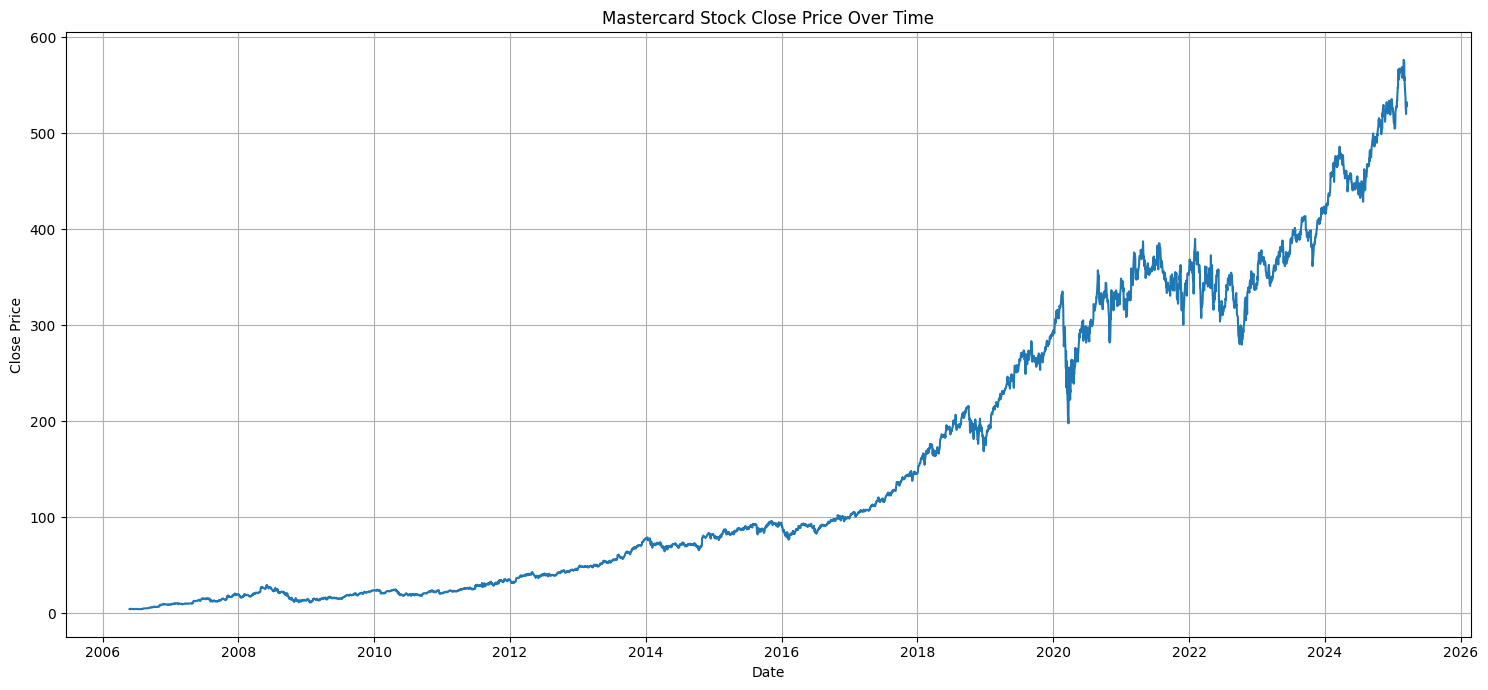

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Date' column is datetime type for plotting, explicitly converting to UTC
df['Date'] = pd.to_datetime(df['Date'], utc=True)

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Close', data=df)
plt.title('Mastercard Stock Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()

### Re-preparing Data for Classification

Re-creating the target variable and `df_classified` after fixing the 'Date' column conversion.

In [27]:
# Create a 'Next Day Close' column to compare with the current day's close
df['Next Day Close'] = df['Close'].shift(-1)

# Create the Target variable: 1 if next day's close is higher, 0 otherwise
df['Target'] = (df['Next Day Close'] > df['Close']).astype(int)

# Drop the last row as it will have NaN for 'Next Day Close' and 'Target'
df_classified = df.dropna(subset=['Target'])

display(df_classified[['Date', 'Close', 'Next Day Close', 'Target']].head())

,Date,Close,Next Day Close,Target
0,2006-05-25 04:00:00+00:00,4.197985,4.100336,0
1,2006-05-26 04:00:00+00:00,4.100336,4.015467,0
2,2006-05-30 04:00:00+00:00,4.015467,4.101250,1
3,2006-05-31 04:00:00+00:00,4.101250,4.335786,1
4,2006-06-01 04:00:00+00:00,4.335786,4.288331,0


Now, extracting additional features from the 'Date' column in the corrected `df_classified`.

In [28]:
# Extract time-based features from 'Date'
df_classified['Year'] = df_classified['Date'].dt.year
df_classified['Month'] = df_classified['Date'].dt.month
df_classified['Day'] = df_classified['Date'].dt.day
df_classified['DayOfWeek'] = df_classified['Date'].dt.dayofweek

display(df_classified.head())

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Next Day Close,Target,Year,Month,Day,DayOfWeek
0,2006-05-25 04:00:00+00:00,3.677800,4.202548,3.668674,4.197985,395343000,0.0,0.0,4.100336,0,2006,5,25,3
1,2006-05-26 04:00:00+00:00,4.225363,4.265517,4.025502,4.100336,103044000,0.0,0.0,4.015467,0,2006,5,26,4
2,2006-05-30 04:00:00+00:00,4.103990,4.104902,3.910517,4.015467,49898000,0.0,0.0,4.101250,1,2006,5,30,1
3,2006-05-31 04:00:00+00:00,4.047406,4.139579,4.047406,4.101250,30002000,0.0,0.0,4.335786,1,2006,5,31,2
4,2006-06-01 04:00:00+00:00,4.100334,4.389630,4.097596,4.335786,62344000,0.0,0.0,4.288331,0,2006,6,1,3


### Model Training for Classification

Defining features and target, splitting data, and training the classification model.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define features (X) and target (y)
# Drop 'Date', 'Next Day Close', and original stock price columns that are directly related to the target
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Year', 'Month', 'Day', 'DayOfWeek']
X = df_classified[features]
y = df_classified['Target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 3786 samples
Test set size: 947 samples


Now, I will train a `RandomForestClassifier` model and evaluate its performance.

In [30]:
# Initialize and train the RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.5364

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.43      0.46       437
           1       0.56      0.63      0.59       510

    accuracy                           0.54       947
   macro avg       0.53      0.53      0.53       947
weighted avg       0.53      0.54      0.53       947



### Re-preparing Data for Classification

Re-creating the target variable and `df_classified` after fixing the 'Date' column conversion.

In [23]:
# Create a 'Next Day Close' column to compare with the current day's close
df['Next Day Close'] = df['Close'].shift(-1)

# Create the Target variable: 1 if next day's close is higher, 0 otherwise
df['Target'] = (df['Next Day Close'] > df['Close']).astype(int)

# Drop the last row as it will have NaN for 'Next Day Close' and 'Target'
df_classified = df.dropna(subset=['Target'])

display(df_classified[['Date', 'Close', 'Next Day Close', 'Target']].head())

,Date,Close,Next Day Close,Target
0,2006-05-25 04:00:00+00:00,4.197985,4.100336,0
1,2006-05-26 04:00:00+00:00,4.100336,4.015467,0
2,2006-05-30 04:00:00+00:00,4.015467,4.101250,1
3,2006-05-31 04:00:00+00:00,4.101250,4.335786,1
4,2006-06-01 04:00:00+00:00,4.335786,4.288331,0


Now, extracting additional features from the 'Date' column in the corrected `df_classified`.

In [24]:
# Extract time-based features from 'Date'
df_classified['Year'] = df_classified['Date'].dt.year
df_classified['Month'] = df_classified['Date'].dt.month
df_classified['Day'] = df_classified['Date'].dt.day
df_classified['DayOfWeek'] = df_classified['Date'].dt.dayofweek

display(df_classified.head())

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Next Day Close,Target,Year,Month,Day,DayOfWeek
0,2006-05-25 04:00:00+00:00,3.677800,4.202548,3.668674,4.197985,395343000,0.0,0.0,4.100336,0,2006,5,25,3
1,2006-05-26 04:00:00+00:00,4.225363,4.265517,4.025502,4.100336,103044000,0.0,0.0,4.015467,0,2006,5,26,4
2,2006-05-30 04:00:00+00:00,4.103990,4.104902,3.910517,4.015467,49898000,0.0,0.0,4.101250,1,2006,5,30,1
3,2006-05-31 04:00:00+00:00,4.047406,4.139579,4.047406,4.101250,30002000,0.0,0.0,4.335786,1,2006,5,31,2
4,2006-06-01 04:00:00+00:00,4.100334,4.389630,4.097596,4.335786,62344000,0.0,0.0,4.288331,0,2006,6,1,3


### Model Training for Classification

Defining features and target, splitting data, and training the classification model.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define features (X) and target (y)
# Drop 'Date', 'Next Day Close', and original stock price columns that are directly related to the target
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Year', 'Month', 'Day', 'DayOfWeek']
X = df_classified[features]
y = df_classified['Target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 3786 samples
Test set size: 947 samples


Now, I will train a `RandomForestClassifier` model and evaluate its performance.

In [26]:
# Initialize and train the RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.5364

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.43      0.46       437
           1       0.56      0.63      0.59       510

    accuracy                           0.54       947
   macro avg       0.53      0.53      0.53       947
weighted avg       0.53      0.54      0.53       947



### Preparing Data for Classification

For a categorization task with stock data, we often predict the direction of the stock price. I will create a `Target` column which will be `1` if the `Close` price increases on the next day, and `0` otherwise.

In [14]:
# Create a 'Next Day Close' column to compare with the current day's close
df['Next Day Close'] = df['Close'].shift(-1)

# Create the Target variable: 1 if next day's close is higher, 0 otherwise
df['Target'] = (df['Next Day Close'] > df['Close']).astype(int)

# Drop the last row as it will have NaN for 'Next Day Close' and 'Target'
df_classified = df.dropna(subset=['Target'])

display(df_classified[['Date', 'Close', 'Next Day Close', 'Target']].head())

,Date,Close,Next Day Close,Target
0,2006-05-25 00:00:00-04:00,4.197985,4.100336,0
1,2006-05-26 00:00:00-04:00,4.100336,4.015467,0
2,2006-05-30 00:00:00-04:00,4.015467,4.101250,1
3,2006-05-31 00:00:00-04:00,4.101250,4.335786,1
4,2006-06-01 00:00:00-04:00,4.335786,4.288331,0


Next, I will extract some additional features from the 'Date' column that might be useful for prediction, such as year, month, day, and day of the week.

In [16]:
# Extract time-based features from 'Date'
df_classified['Year'] = df_classified['Date'].dt.year
df_classified['Month'] = df_classified['Date'].dt.month
df_classified['Day'] = df_classified['Date'].dt.day
df_classified['DayOfWeek'] = df_classified['Date'].dt.dayofweek

display(df_classified.head())

AttributeError: Can only use .dt accessor with datetimelike values

### Model Training for Classification

Now I will define the features (X) and the target variable (y), split the data into training and testing sets, and then train a classification model.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define features (X) and target (y)
# Drop 'Date', 'Next Day Close', and original stock price columns that are directly related to the target
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Year', 'Month', 'Day', 'DayOfWeek']
X = df_classified[features]
y = df_classified['Target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 3786 samples
Test set size: 947 samples


Now, I will train a `RandomForestClassifier` model and evaluate its performance.

In [32]:
# Initialize and train the RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.5364

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.43      0.46       437
           1       0.56      0.63      0.59       510

    accuracy                           0.54       947
   macro avg       0.53      0.53      0.53       947
weighted avg       0.53      0.54      0.53       947



### Model Training for Classification

Now I will define the features (X) and the target variable (y), split the data into training and testing sets, and then train a classification model.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define features (X) and target (y)
# Drop 'Date', 'Next Day Close', and original stock price columns that are directly related to the target
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Year', 'Month', 'Day', 'DayOfWeek']
X = df_classified[features]
y = df_classified['Target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 3786 samples
Test set size: 947 samples


Now, I will train a `RandomForestClassifier` model and evaluate its performance.

In [34]:
# Initialize and train the RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.5364

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.43      0.46       437
           1       0.56      0.63      0.59       510

    accuracy                           0.54       947
   macro avg       0.53      0.53      0.53       947
weighted avg       0.53      0.54      0.53       947

